# Homework 1

这次作业包括图像的噪声和滤波

In [ ]:
# Setup
import numpy as np

import matplotlib.pyplot as plt
from skimage import io

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2
# Load the image
img = io.imread('lena.png')

### 任务1：实现高斯噪声

### 任务目标
- 理解高斯噪声的数学模型
- 掌握如何向干净图像中人工添加高斯噪声
- 观察不同方差参数对噪声强度的影响

高斯噪声是一种**概率密度函数服从高斯分布（正态分布）**的噪声。在图像中，它表现为每个像素值被添加了一个随机值，这个随机值服从高斯分布。

对于一幅灰度图像，添加高斯噪声的公式为：
$$G(x,y) = f(x,y) + n(x,y)$$

其中：
- $f(x,y)$ 是原始图像在位置 $(x,y)$ 的像素值
- $n(x,y)$ 是添加的噪声值，$n \sim \mathcal{N}(0, \sigma^2)$，即服从均值为0、方差为$\sigma^2$的高斯分布

$$p(z) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(z-\mu)^2}{2\sigma^2}}$$

在图像处理中，通常取$\mu = 0$，即噪声均值为0，不会改变图像的整体亮度。

In [ ]:
def add_gaussian_noise(image, sigma):
    """
    向图像添加高斯噪声

    Parameters:
        image: numpy.ndarray, 输入的灰度图像，shape (H, W)，dtype=uint8
        sigma: float, 高斯噪声的标准差

    Returns:
        noisy_image: numpy.ndarray, 添加噪声后的图像，dtype=uint8
        noise: numpy.ndarray, 添加的噪声数组，dtype=float
    """
    ### YOUR CODE HERE

    # 生成与图像同尺寸的高斯噪声

    # 将图像转换为 float 以便加噪声，然后裁剪到 [0, 255]

    ### YOUR CODE END

    return noisy.astype(np.uint8), noise

$\sigma = 25$

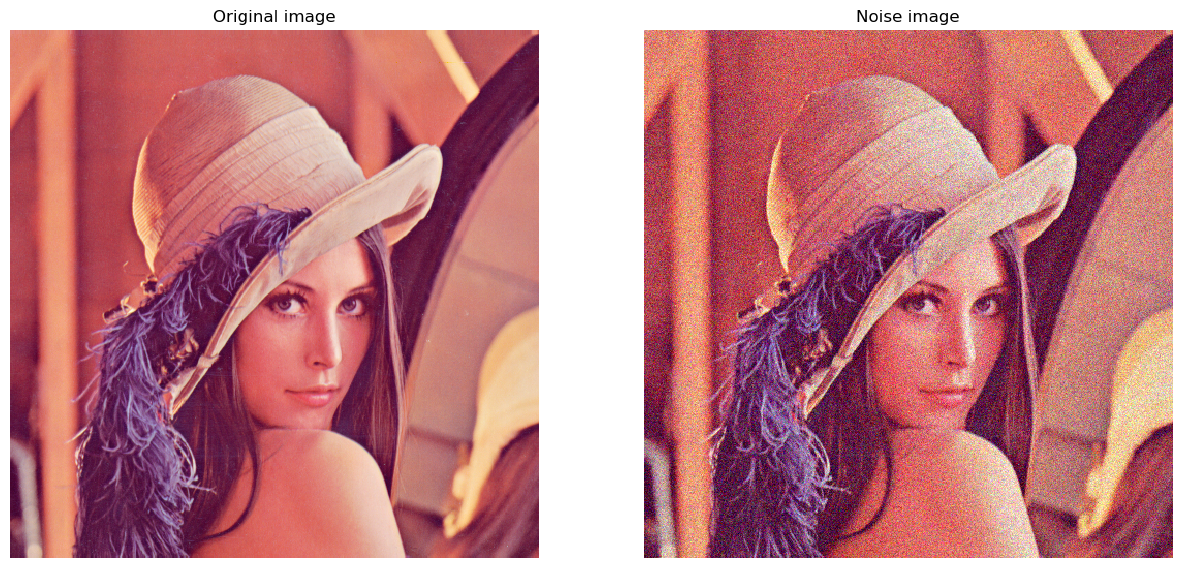

In [29]:
# Set the seed
np.random.seed(47)

noise_image, _ = add_gaussian_noise(img, sigma=25)

plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(noise_image)
plt.title('Noise image')
plt.axis('off')

plt.show()


# Value Test
noise_image_ref = np.load('./references/noise_image.npy')

if not np.allclose(noise_image, noise_image_ref):
    print('Incorrect values! Please check your implementation.')

### 任务2：手动实现卷积和均值滤波

### 任务目标
- 理解卷积的实现
- 实现zero padding的卷积
- 实现均值滤波

### 什么是卷积？
卷积是两个函数之间的一种数学运算，在图像处理中，我们用卷积核（kernel）对图像进行滤波操作。

### 离散二维卷积公式

对于图像 $f$ 和卷积核 $h$，卷积操作定义为：

$$(f * h)(x,y) = \sum_{i=-a}^{a}\sum_{j=-b}^{b} f(x-i, y-j) \cdot h(i,j)$$

其中，卷积核的大小为 $(2a+1) \times (2b+1)$。

### 卷积的物理意义
- **平滑/模糊**：用邻域像素的平均值代替当前像素
- **锐化**：突出像素与邻域的差异
- **边缘检测**：检测像素值的变化率
- **特征提取**：提取特定的图像特征

### 卷积核与滤波器的关系
| 滤波器类型 | 3×3卷积核 | 特点 |
|-----------|-----------|------|
| 均值滤波 | $\frac{1}{9}\begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix}$ | 所有权重相等 |
| 高斯滤波 | $\frac{1}{16}\begin{bmatrix} 1 & 2 & 1 \\ 2 & 4 & 2 \\ 1 & 2 & 1 \end{bmatrix}$ | 中心权重最大 |
| 锐化滤波 | $\begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$ | 增强边缘 |


In [ ]:
def conv2d(image, kernel, pad):
    """
    Convolve `image` with `kernel` using zero padding.

    Args:
        image: 2D numpy array.
        kernel: 2D numpy array.
        pad: int, padding width on all sides.

    Returns:
        out: 2D numpy array of same shape as `image`.
    """
    ### YOUR CODE HERE

    
    ### YOUR CODE END

    return out

均值滤波测试

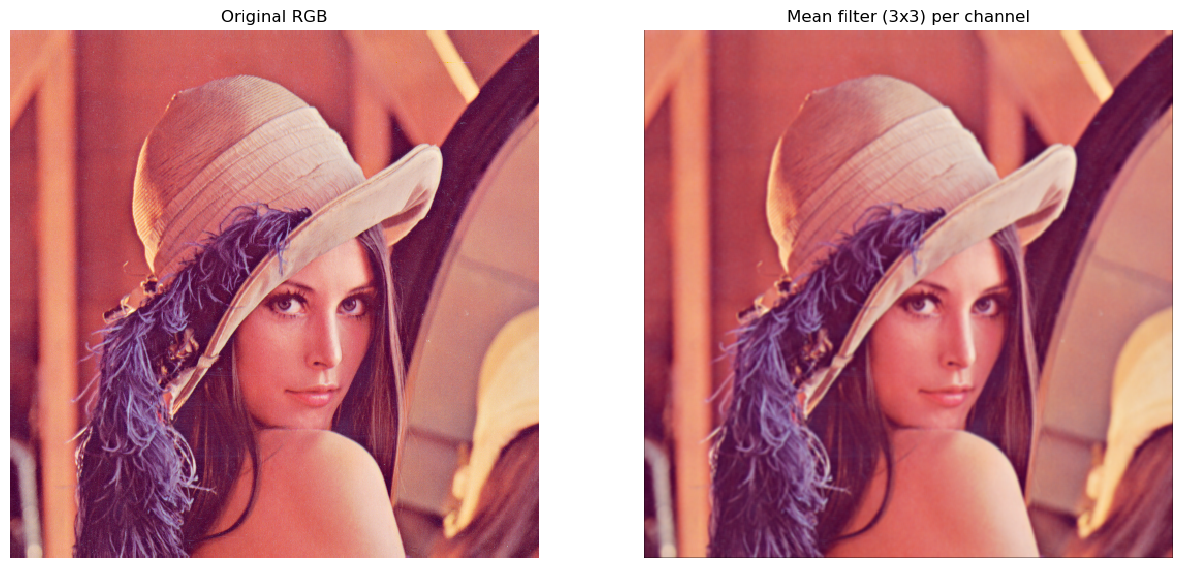

In [30]:
# build 3x3 mean kernel
mean_kernel = np.ones((3, 3), dtype=np.float32) / 9.0

# apply mean filter to each RGB channel separately
filtered_rgb = np.zeros_like(img, dtype=np.uint8)

for c in range(3):
    channel = img[:, :, c].astype(np.float32)
    filtered_channel = conv2d(channel, mean_kernel, pad=1)
    filtered_rgb[:, :, c] = np.clip(filtered_channel, 0, 255).astype(np.uint8)

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_rgb)
plt.title('Mean filter (3x3) per channel')
plt.axis('off')

plt.show()

# Value Test
filtered_rgb_ref = np.load('./references/filtered_rgb.npy')

if not np.allclose(filtered_rgb, filtered_rgb_ref):
    print('Incorrect values! Please check your implementation.')